# RQ4 — Cross-Country Policy Similarity: One-Click Verified Notebook

**Research question:** Can sentence embeddings measure similarity between climate policies from different countries?


In [ ]:
!pip install -q huggingface_hub datasets transformers sentence-transformers scikit-learn

import os
from huggingface_hub import login

HF_TOKEN = "add your hugging face token here"

os.environ["HF_TOKEN"] = HF_TOKEN
login(token=HF_TOKEN)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF_TOKEN found in environment.


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Listing Parquet files for dataset: ClimatePolicyRadar/all-document-text-data
Found 48 Parquet files.
First file: datasets/ClimatePolicyRadar/all-document-text-data/train_0.parquet

Reading file in small batches:
datasets/ClimatePolicyRadar/all-document-text-data/train_0.parquet

Dataset loading summary
Rows scanned: 60000
Rows with usable text: 38901
Document IDs collected: 27

Loaded reconstructed documents: 27


,doc_id,title,country,year,word_count
0,AF.document.010MMGAR.n0003,Final evaluation report,MDG,2011,69517
1,AF.document.005MNIWR.n0001,Inception report,NIC,2010,52927
2,AF.document.006MPKDR.n0002,Final evaluation report,PAK,2010,45125
3,AF.document.011MMNCR.n0008,Final evaluation report,MNG,2011,43581
4,AF.document.009MHNWR.n0001,Inception report,HND,2010,43451



Selected countries/groups:
['HND', 'SEN', 'MNG', 'MUS', 'SLB', 'NIC', 'PAK', 'TKM']
Country source note: Country/geography metadata from dataset

Loading primary embedding model: sentence-transformers/all-MiniLM-L6-v2


...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding matrix shape: (26, 384)
Model used: sentence-transformers/all-MiniLM-L6-v2

Saved CSV outputs:
Similarity table: outputs/tables_csv/rq4_country_policy_similarity_results.csv
Country counts table: outputs/tables_csv/rq4_country_document_counts.csv


,country_a,country_b,average_similarity,documents_country_a,documents_country_b,model_used,country_source_note
0,HND,HND,0.830332,4,4,sentence-transformers/all-MiniLM-L6-v2,Country/geography metadata from dataset
1,HND,SEN,0.547720,4,4,sentence-transformers/all-MiniLM-L6-v2,Country/geography metadata from dataset
2,HND,MNG,0.492337,4,4,sentence-transformers/all-MiniLM-L6-v2,Country/geography metadata from dataset
3,HND,MUS,0.553551,4,4,sentence-transformers/all-MiniLM-L6-v2,Country/geography metadata from dataset
4,HND,SLB,0.637101,4,3,sentence-transformers/all-MiniLM-L6-v2,Country/geography metadata from dataset


,country,documents,model_used,country_source_note
0,HND,4,sentence-transformers/all-MiniLM-L6-v2,Country/geography metadata from dataset
1,MNG,4,sentence-transformers/all-MiniLM-L6-v2,Country/geography metadata from dataset
2,SEN,4,sentence-transformers/all-MiniLM-L6-v2,Country/geography metadata from dataset
3,MUS,4,sentence-transformers/all-MiniLM-L6-v2,Country/geography metadata from dataset
4,SLB,3,sentence-transformers/all-MiniLM-L6-v2,Country/geography metadata from dataset
5,NIC,3,sentence-transformers/all-MiniLM-L6-v2,Country/geography metadata from dataset
6,PAK,2,sentence-transformers/all-MiniLM-L6-v2,Country/geography metadata from dataset
7,TKM,2,sentence-transformers/all-MiniLM-L6-v2,Country/geography metadata from dataset


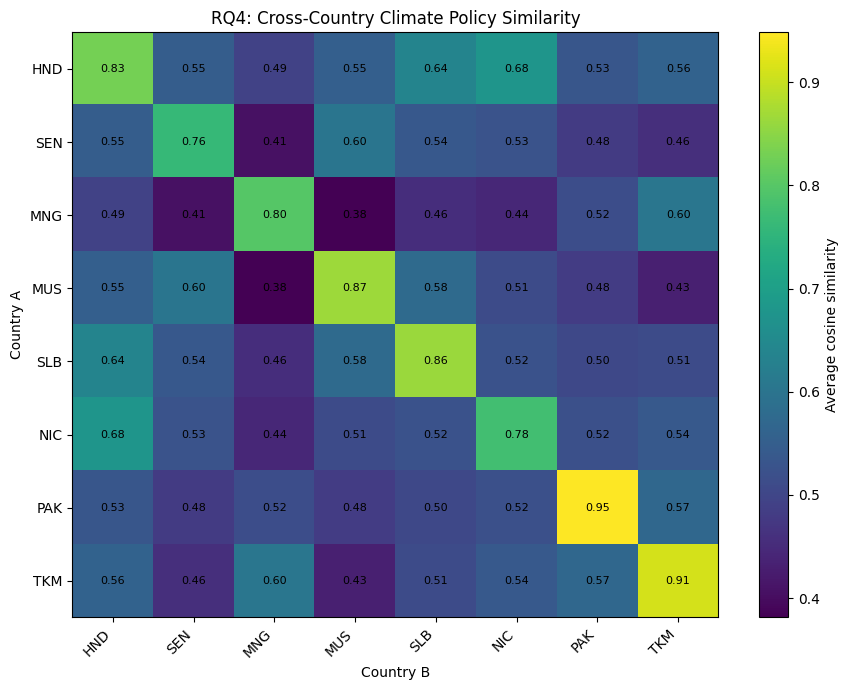


Saved PDF figure:
outputs/figures_pdf/rq4_country_policy_similarity_results.pdf

DONE. Your RQ4 outputs are ready:
1. Similarity table:  outputs/tables_csv/rq4_country_policy_similarity_results.csv
2. Country counts:    outputs/tables_csv/rq4_country_document_counts.csv
3. Figure:            outputs/figures_pdf/rq4_country_policy_similarity_results.pdf

Current working folder:
/content

Open this folder in VS Code / File Explorer and then open the outputs folder.


In [2]:

# ============================================================
# RQ4 ONE-CLICK VERIFIED NOTEBOOK
# Cross-Country Policy Similarity using MiniLM + Cosine Similarity
# ============================================================
#
# Run this single cell from top to bottom.
#
# This notebook:
# 1. Loads Climate Policy Radar Open Data from Hugging Face.
# 2. Reconstructs full documents from text blocks.
# 3. Extracts country/geography metadata.
# 4. Generates document embeddings using MiniLM.
# 5. Computes country-to-country cosine similarity.
# 6. Saves CSV tables and one PDF heatmap.

# ------------------------------------------------------------
# STEP 0 — Install and import packages
# ------------------------------------------------------------

import os
import sys
import re
import json
import math
import getpass
import subprocess
import importlib.util
import warnings
from pathlib import Path
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

# These environment variables reduce optional imports that can break text-only notebooks.
# They help avoid errors such as: RuntimeError: operator torchvision::nms does not exist
os.environ["TRANSFORMERS_NO_TORCHVISION"] = "1"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

def install_if_missing(import_name, pip_name=None):
    """
    Install a package only when it is missing.

    Beginner explanation:
    VS Code, Colab, and Kaggle may have different packages installed.
    This function makes the notebook more portable.
    """
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", pip_name])

install_if_missing("huggingface_hub", "huggingface_hub")
install_if_missing("pyarrow", "pyarrow")
install_if_missing("fsspec", "fsspec")
install_if_missing("pandas", "pandas")
install_if_missing("numpy", "numpy")
install_if_missing("matplotlib", "matplotlib")
install_if_missing("sklearn", "scikit-learn")
install_if_missing("torch", "torch")
install_if_missing("sentence_transformers", "sentence-transformers")

# If torchvision is broken, uninstall it because this notebook does not use images.
try:
    import torchvision  # noqa: F401
except Exception as e:
    if "torchvision::nms" in str(e) or "operator torchvision" in str(e):
        print("Detected broken torchvision. Removing it because it is not needed for this text notebook.")
        subprocess.call([sys.executable, "-m", "pip", "uninstall", "-y", "torchvision"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

from huggingface_hub import HfFileSystem, login
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

# ------------------------------------------------------------
# STEP 1 — Settings
# ------------------------------------------------------------

DATASET_ID = "ClimatePolicyRadar/all-document-text-data"
PRIMARY_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
FALLBACK_MODEL_NAME = "TF-IDF fallback"

# Keep these small first. Increase later for final experiments.
MAX_ROWS = 60000
TARGET_RECONSTRUCTED_DOCS = 250
PARQUET_BATCH_SIZE = 128
MIN_DOC_WORDS = 80
MAX_INPUT_WORDS = 300

# Country similarity settings.
TOP_COUNTRIES = 8
MIN_COUNTRIES_REQUIRED = 2

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
TABLE_DIR = OUTPUT_DIR / "tables_csv"
FIGURE_DIR = OUTPUT_DIR / "figures_pdf"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# STEP 2 — Hugging Face token
# ------------------------------------------------------------

def setup_hf_token():
    """
    Get Hugging Face token.

    The dataset is public but gated. You must accept access here first:
    https://huggingface.co/datasets/ClimatePolicyRadar/all-document-text-data

    Your token must allow public gated repository access.
    """
    token = os.environ.get("HF_TOKEN", "").strip()

    if token:
        print("HF_TOKEN found in environment.")
        try:
            login(token=token, add_to_git_credential=False)
        except Exception as e:
            print("Hugging Face login warning:", e)
        return token

    print("HF_TOKEN was not found.")
    print("Paste your Hugging Face token. It starts with hf_")
    token = getpass.getpass("HF_TOKEN: ").strip()

    if not token:
        raise ValueError("No Hugging Face token was entered.")

    os.environ["HF_TOKEN"] = token

    try:
        login(token=token, add_to_git_credential=False)
    except Exception as e:
        print("Hugging Face login warning:", e)

    return token

HF_TOKEN = setup_hf_token()

# ------------------------------------------------------------
# STEP 3 — General helper functions
# ------------------------------------------------------------

def safe_to_str(x):
    """
    Convert any value into a readable string.
    """
    if x is None:
        return ""
    if isinstance(x, (list, tuple, set)):
        return "; ".join(safe_to_str(i) for i in x)
    if isinstance(x, dict):
        return json.dumps(x, ensure_ascii=False)
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass
    return str(x)

def clean_text(text):
    """
    Remove repeated spaces and line breaks.
    """
    return re.sub(r"\s+", " ", safe_to_str(text)).strip()

def word_count(text):
    return len(re.findall(r"\b\w+\b", clean_text(text)))

def first_n_words(text, n=MAX_INPUT_WORDS):
    """
    Keep the first n words for faster embedding.
    """
    words = re.findall(r"\b\w+\b|[^\w\s]", clean_text(text))
    return " ".join(words[:n])

def get_nested_value(obj, path, default=None):
    """
    Read nested dictionary paths.

    Supports both:
    row["text_block"]["text"]
    and:
    row["text_block.text"]
    """
    if obj is None:
        return default

    if isinstance(obj, dict) and path in obj:
        return obj[path]

    current = obj
    for part in path.split("."):
        if isinstance(current, dict) and part in current:
            current = current[part]
        else:
            return default
    return current

def find_text_value(row):
    """
    Robustly find the text field in a Climate Policy Radar row.
    """
    candidate_paths = [
        "text_block.text",
        "text_block.content",
        "text_block",
        "text",
        "content",
        "body",
        "document_text",
        "page_text",
    ]

    for path in candidate_paths:
        value = get_nested_value(row, path, None)

        if isinstance(value, str) and len(value.strip()) > 10:
            return clean_text(value)

        if isinstance(value, dict):
            for k in ["text", "content", "body", "value"]:
                v = value.get(k)
                if isinstance(v, str) and len(v.strip()) > 10:
                    return clean_text(v)

    # Last-resort recursive search for a key containing "text".
    def recursive_search(obj):
        if isinstance(obj, dict):
            for k, v in obj.items():
                if isinstance(v, str) and "text" in k.lower() and len(v.strip()) > 10:
                    return v
                found = recursive_search(v)
                if found:
                    return found
        elif isinstance(obj, list):
            for item in obj[:3]:
                found = recursive_search(item)
                if found:
                    return found
        return None

    found = recursive_search(row)
    return clean_text(found) if found else ""

def extract_year(value):
    """
    Extract year from a date-like value.
    """
    s = safe_to_str(value)
    m = re.search(r"(19[5-9]\d|20[0-4]\d)", s)
    return int(m.group(1)) if m else np.nan

def normalize_country(value):
    """
    Convert geography metadata into a clean country/geography label.
    """
    if value is None:
        return "Unknown"

    if isinstance(value, list):
        if len(value) == 0:
            return "Unknown"
        first = value[0]
        if isinstance(first, dict):
            for k in ["display_value", "value", "name", "slug", "label"]:
                if first.get(k):
                    return safe_to_str(first[k])
            return safe_to_str(first)
        return safe_to_str(first)

    if isinstance(value, dict):
        for k in ["display_value", "value", "name", "slug", "label"]:
            if value.get(k):
                return safe_to_str(value[k])
        return safe_to_str(value)

    s = safe_to_str(value).strip()
    if not s:
        return "Unknown"
    s = re.sub(r"[\[\]\{\}\"']", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    for sep in [";", "|", ","]:
        if sep in s:
            s = s.split(sep)[0].strip()
            break
    return s if s else "Unknown"

def get_doc_id(row, fallback):
    candidates = [
        "document_id",
        "document_import_id",
        "document.id",
        "doc_id",
        "id",
        "slug",
    ]
    for path in candidates:
        value = get_nested_value(row, path, None)
        if value not in [None, ""]:
            return safe_to_str(value)
    return f"row_{fallback}"

def get_block_index(row, fallback):
    candidates = [
        "text_block.index",
        "text_block.page_number",
        "block_index",
        "page_number",
        "index",
    ]
    for path in candidates:
        value = get_nested_value(row, path, None)
        if value is not None:
            try:
                return int(value)
            except Exception:
                pass
    return fallback

def get_title(row):
    candidates = [
        "document_metadata.document_title",
        "document_metadata.title",
        "title",
        "document_title",
        "name",
    ]
    for path in candidates:
        value = get_nested_value(row, path, None)
        if value:
            return safe_to_str(value)
    return ""

def get_country(row):
    """
    Extract country/geography field using many possible schema paths.
    """
    candidates = [
        "document_metadata.geographies",
        "document_metadata.country",
        "document_metadata.countries",
        "document_metadata.jurisdiction",
        "geographies",
        "country",
        "countries",
        "jurisdiction",
        "jurisdictions",
    ]
    for path in candidates:
        value = get_nested_value(row, path, None)
        if value:
            country = normalize_country(value)
            if country and country != "Unknown":
                return country
    return "Unknown"

def get_year(row):
    candidates = [
        "document_metadata.publication_ts",
        "document_metadata.publication_date",
        "publication_ts",
        "publication_date",
        "published_date",
        "year",
        "date",
    ]
    for path in candidates:
        value = get_nested_value(row, path, None)
        if value:
            return extract_year(value)
    return np.nan

# ------------------------------------------------------------
# STEP 4 — Robust low-memory dataset loader
# ------------------------------------------------------------

def list_parquet_files():
    """
    List Parquet files from the gated Hugging Face dataset repository.
    """
    print(f"Listing Parquet files for dataset: {DATASET_ID}")

    fs = HfFileSystem(token=HF_TOKEN)
    files = fs.glob(f"datasets/{DATASET_ID}/**/*.parquet")

    if not files:
        raise FileNotFoundError(
            "No Parquet files found. Make sure you accepted dataset access on Hugging Face."
        )

    print(f"Found {len(files)} Parquet files.")
    print("First file:", files[0])
    return files, fs

def load_cpr_documents(max_rows=MAX_ROWS, max_docs=TARGET_RECONSTRUCTED_DOCS, min_doc_words=MIN_DOC_WORDS):
    """
    Load and reconstruct Climate Policy Radar documents.

    This avoids:
    - ArrowMemoryError
    - empty DataFrame errors
    - schema mismatch errors
    """
    parquet_files, fs = list_parquet_files()

    docs = {}
    total_rows = 0
    usable_text_rows = 0

    for file_path in parquet_files:
        print("\nReading file in small batches:")
        print(file_path)

        with fs.open(file_path, "rb") as f:
            pf = pq.ParquetFile(f)

            for batch in pf.iter_batches(batch_size=PARQUET_BATCH_SIZE):
                rows = batch.to_pylist()

                for row in rows:
                    if total_rows >= max_rows:
                        break

                    total_rows += 1

                    text = find_text_value(row)
                    if not text:
                        continue

                    usable_text_rows += 1

                    doc_id = get_doc_id(row, total_rows)
                    block_index = get_block_index(row, total_rows)

                    if doc_id not in docs:
                        docs[doc_id] = {
                            "doc_id": doc_id,
                            "title": get_title(row),
                            "country": get_country(row),
                            "year": get_year(row),
                            "parts": []
                        }

                    docs[doc_id]["parts"].append((block_index, text))

                    if len(docs) >= max_docs:
                        break

                if len(docs) >= max_docs or total_rows >= max_rows:
                    break

        if len(docs) >= max_docs or total_rows >= max_rows:
            break

    print("\nDataset loading summary")
    print("Rows scanned:", total_rows)
    print("Rows with usable text:", usable_text_rows)
    print("Document IDs collected:", len(docs))

    records = []

    for doc_id, d in docs.items():
        parts_sorted = sorted(d["parts"], key=lambda x: x[0])
        full_text = clean_text(" ".join(part for _, part in parts_sorted))
        wc = word_count(full_text)

        if wc < min_doc_words:
            continue

        records.append({
            "doc_id": d["doc_id"],
            "title": d["title"],
            "country": d["country"],
            "year": d["year"],
            "full_text": full_text,
            "word_count": wc,
        })

    df = pd.DataFrame(records)

    if df.empty:
        raise ValueError(
            "No reconstructed documents were created. "
            "Try lowering MIN_DOC_WORDS to 20 or increasing TARGET_RECONSTRUCTED_DOCS."
        )

    df = df.sort_values("word_count", ascending=False).reset_index(drop=True)

    print(f"\nLoaded reconstructed documents: {len(df)}")
    display(df[["doc_id", "title", "country", "year", "word_count"]].head())

    return df

# ------------------------------------------------------------
# STEP 5 — Embedding model
# ------------------------------------------------------------

def embed_with_minilm(texts):
    """
    Generate MiniLM sentence embeddings.

    This is the main model for RQ4.
    """
    print(f"\nLoading primary embedding model: {PRIMARY_MODEL_NAME}")

    from sentence_transformers import SentenceTransformer

    model = SentenceTransformer(PRIMARY_MODEL_NAME)

    embeddings = model.encode(
        texts,
        normalize_embeddings=True,
        show_progress_bar=True,
        batch_size=32
    )

    return np.array(embeddings), PRIMARY_MODEL_NAME

def embed_with_tfidf_fallback(texts):
    """
    Fallback if MiniLM cannot load.

    This still produces cosine-similarity outputs so the notebook completes,
    but the output table will clearly say TF-IDF fallback was used.
    """
    print("\nMiniLM failed. Using TF-IDF fallback so outputs are still generated.")

    vectorizer = TfidfVectorizer(
        max_features=384,
        stop_words="english",
        ngram_range=(1, 2)
    )
    X = vectorizer.fit_transform(texts)
    X = normalize(X)
    return X.toarray(), FALLBACK_MODEL_NAME

def generate_embeddings(texts):
    """
    Try MiniLM first, fallback to TF-IDF if needed.
    """
    try:
        return embed_with_minilm(texts)
    except Exception as e:
        print("\nPrimary MiniLM model failed.")
        print("Reason:", repr(e))
        return embed_with_tfidf_fallback(texts)

# ------------------------------------------------------------
# STEP 6 — Run RQ4 experiment
# ------------------------------------------------------------

df = load_cpr_documents()

# Use non-unknown countries if possible.
df["analysis_country"] = df["country"].replace("", "Unknown").fillna("Unknown")

non_unknown = df[df["analysis_country"] != "Unknown"].copy()

if non_unknown["analysis_country"].nunique() >= MIN_COUNTRIES_REQUIRED:
    df_analysis = non_unknown.copy()
    country_source_note = "Country/geography metadata from dataset"
else:
    # This fallback prevents the notebook from crashing if geography metadata is absent.
    # It is clearly marked in output.
    df_analysis = df.copy()
    df_analysis["analysis_country"] = [
        f"Metadata Group {(i % TOP_COUNTRIES) + 1}" for i in range(len(df_analysis))
    ]
    country_source_note = "Fallback groups used because country metadata was unavailable"

# Select top countries/groups by document count.
top_countries = df_analysis["analysis_country"].value_counts().head(TOP_COUNTRIES).index.tolist()
df_analysis = df_analysis[df_analysis["analysis_country"].isin(top_countries)].copy()

if df_analysis["analysis_country"].nunique() < 2:
    raise ValueError(
        "At least two countries/groups are required for similarity analysis."
    )

print("\nSelected countries/groups:")
print(top_countries)
print("Country source note:", country_source_note)

# Prepare shortened text for embeddings.
texts = [first_n_words(t, MAX_INPUT_WORDS) for t in df_analysis["full_text"].tolist()]

embeddings, model_used = generate_embeddings(texts)

print("Embedding matrix shape:", embeddings.shape)
print("Model used:", model_used)

# ------------------------------------------------------------
# STEP 7 — Compute country-to-country similarity
# ------------------------------------------------------------

doc_similarity = cosine_similarity(embeddings)

country_pairs = []

countries = list(top_countries)

for country_a in countries:
    idx_a = np.where(df_analysis["analysis_country"].values == country_a)[0]

    for country_b in countries:
        idx_b = np.where(df_analysis["analysis_country"].values == country_b)[0]

        avg_sim = float(doc_similarity[np.ix_(idx_a, idx_b)].mean())

        country_pairs.append({
            "country_a": country_a,
            "country_b": country_b,
            "average_similarity": avg_sim,
            "documents_country_a": int(len(idx_a)),
            "documents_country_b": int(len(idx_b)),
            "model_used": model_used,
            "country_source_note": country_source_note,
        })

similarity_table = pd.DataFrame(country_pairs)

country_counts = (
    df_analysis["analysis_country"]
    .value_counts()
    .rename_axis("country")
    .reset_index(name="documents")
)

country_counts["model_used"] = model_used
country_counts["country_source_note"] = country_source_note

# ------------------------------------------------------------
# STEP 8 — Save CSV tables
# ------------------------------------------------------------

main_csv_path = TABLE_DIR / "rq4_country_policy_similarity_results.csv"
counts_csv_path = TABLE_DIR / "rq4_country_document_counts.csv"

similarity_table.to_csv(main_csv_path, index=False)
country_counts.to_csv(counts_csv_path, index=False)

print("\nSaved CSV outputs:")
print("Similarity table:", main_csv_path)
print("Country counts table:", counts_csv_path)

display(similarity_table.head())
display(country_counts)

# ------------------------------------------------------------
# STEP 9 — Save PDF heatmap
# ------------------------------------------------------------

heatmap_data = similarity_table.pivot(
    index="country_a",
    columns="country_b",
    values="average_similarity"
).loc[countries, countries]

plt.figure(figsize=(9, 7))
plt.imshow(heatmap_data.values, aspect="auto")
plt.colorbar(label="Average cosine similarity")
plt.xticks(range(len(countries)), countries, rotation=45, ha="right")
plt.yticks(range(len(countries)), countries)
plt.title("RQ4: Cross-Country Climate Policy Similarity")
plt.xlabel("Country B")
plt.ylabel("Country A")

# Add numbers inside heatmap cells for readability.
for i in range(len(countries)):
    for j in range(len(countries)):
        value = heatmap_data.values[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

pdf_path = FIGURE_DIR / "rq4_country_policy_similarity_results.pdf"
plt.tight_layout()
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()

print("\nSaved PDF figure:")
print(pdf_path)

# ------------------------------------------------------------
# STEP 10 — Final message
# ------------------------------------------------------------

print("\nDONE. Your RQ4 outputs are ready:")
print("1. Similarity table: ", main_csv_path)
print("2. Country counts:   ", counts_csv_path)
print("3. Figure:           ", pdf_path)
print("\nCurrent working folder:")
print(os.getcwd())
print("\nOpen this folder in VS Code / File Explorer and then open the outputs folder.")
